# TQ-IoT: Multi-Objective IoT Sensor Scheduling
## Battery Lifetime · Age of Information · Radio Channel Quality
### FIT IoT-Lab Experiment Pipeline — Master Thesis 2026

**Authors:** Abhay Singh & Peeyush Kelkar | Stockholm University | Spring 2026

---

**Sections:**
1. Configuration — set experiment ID, derive all paths
2. Imports — standard libraries only
3. Sensor Parsing — parse temperature, luminosity, pressure
4. Power Parsing — parse OML files, derive real energy costs
5. Radio Parsing — parse RSSI, convert to channel quality bins
6. Feature Engineering — build per-step RL trace
7. RL Environment — battery, AoI, channel-aware scheduling
8. Multi-Objective Q-Learning — Chebyshev + weighted-sum
9. Baselines — 8 fixed-rule comparison policies
10. Training and Evaluation — multi-seed experiment
11. Sensitivity Analysis — vary key parameters
12. Ablation Study — remove one feature at a time
13. Plots — 9 thesis-quality figures
14. Reproducibility Summary — full experiment report


## 1. Configuration

In [6]:
from pathlib import Path
import json, warnings
warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════════════════════════
#  CHANGE ONLY THIS — everything else updates automatically
# ══════════════════════════════════════════════════════════════════════════════
EXPERIMENT_ID = 437035

# ── project root detection ────────────────────────────────────────────────────
# Works whether you run from:  notebooks/   OR  project root
def find_project_root() -> Path:
    cwd = Path.cwd()
    if (cwd / "data" / "raw").exists():
        return cwd                  # running from project root
    if (cwd.parent / "data" / "raw").exists():
        return cwd.parent           # running from notebooks/
    raise FileNotFoundError(
        "Cannot find data/raw/. "
        "Run this notebook from the project root or notebooks/ folder.")

ROOT         = find_project_root()
RAW_DIR      = ROOT / "data" / "raw"       / f"exp_{EXPERIMENT_ID}"
PROCESSED    = ROOT / "data" / "processed" / f"exp_{EXPERIMENT_ID}"
RESULTS      = ROOT / "results"            / f"exp_{EXPERIMENT_ID}"
FIGURES      = RESULTS / "figures"

for d in [PROCESSED, RESULTS, FIGURES]:
    d.mkdir(parents=True, exist_ok=True)

if not RAW_DIR.exists():
    raise FileNotFoundError(f"Raw data folder not found: {RAW_DIR}")

# ── experiment settings ───────────────────────────────────────────────────────
SEEDS               = list(range(10))
EPISODES_PER_WEIGHT = 100
EVAL_EPISODES       = 50
AOI_CAP             = 20
BATTERY_CAP         = 100
AOI_STALE_THRESH    = 10

# Weight pairs (wE, wF): wE=energy weight, wF=freshness weight
# Example: (0.1, 0.9) → freshness is 9x more important than energy
#          (0.9, 0.1) → energy saving is 9x more important than freshness
WEIGHTS = [(0.1,0.9), (0.3,0.7), (0.5,0.5), (0.7,0.3), (0.9,0.1)]

# RSSI thresholds for channel quality bins
# RSSI >= -70 dBm      → good   (strong signal, ~95% tx success)
# -85 <= RSSI < -70    → medium (~75% success)
# RSSI < -85           → poor   (~45% success)
RSSI_GOOD   = -70.0
RSSI_MEDIUM = -85.0

# Transmission success probability per channel quality bin
# good=2, medium=1, poor=0
TX_SUCCESS = {2: 0.95, 1: 0.75, 0: 0.45}

# Load experiment metadata if present
_meta = RAW_DIR / f"exp_{EXPERIMENT_ID}_metadata.json"
metadata = json.loads(_meta.read_text()) if _meta.exists() else {}

print(f"Project root   : {ROOT}")
print(f"Experiment ID  : {EXPERIMENT_ID}")
print(f"Raw data       : {RAW_DIR}")
print(f"Results        : {RESULTS}")
print(f"Experiment name: {metadata.get('name', 'N/A')}")
print(f"Seeds          : {SEEDS}")
print(f"Weights        : {WEIGHTS}")


Project root   : d:\thesis-iot-scheduling-
Experiment ID  : 437035
Raw data       : d:\thesis-iot-scheduling-\data\raw\exp_437035
Results        : d:\thesis-iot-scheduling-\results\exp_437035
Experiment name: SENA_Test7
Seeds          : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Weights        : [(0.1, 0.9), (0.3, 0.7), (0.5, 0.5), (0.7, 0.3), (0.9, 0.1)]


## 2. Imports

In [7]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Tuple, List, Dict, Optional

plt.rcParams.update({"font.size": 11, "axes.titlesize": 12,
                     "figure.dpi": 110, "savefig.dpi": 150,
                     "savefig.bbox": "tight"})
print("Imports ready.")


Imports ready.


## 3. Sensor Data Parsing

Source: `exp_437035_sensor_stream_raw.txt`

Line format:
```
timestamp ; node_id ; [cmd >] measurement_type: value unit
```
Example:
```
1777281499.430696;m3-10;Chip temperature measure: 3.01625E1
1777281499.431309;m3-10;cmd > Luminosity measure: 9.765625E-1 lux
1777281499.431492;m3-10;cmd > Pressure measure: 1.0040913E3 mabar
```
Scientific notation (e.g. `3.01625E1`) is handled automatically by Python's `float()`.


In [8]:
def find_sensor_file(raw_dir: Path) -> Optional[Path]:
    """
    Find the sensor stream file.
    Tries the standard FIT IoT-Lab naming pattern first,
    then falls back to any .txt that is not a metadata/runtime file.
    """
    candidates = [
        f"exp_{EXPERIMENT_ID}_sensor_stream_raw.txt",
        "sensor_stream_raw.txt",
        "serial_output.txt",
    ]
    for name in candidates:
        f = raw_dir / name
        if f.exists():
            return f
    txts = [f for f in raw_dir.glob("*.txt")
            if "metadata" not in f.name and "runtime" not in f.name]
    return txts[0] if txts else None


def parse_sensor_stream(path: Path) -> Tuple[pd.DataFrame, float]:
    """
    Parse the FIT IoT-Lab serial log.
    Returns (tidy_df, t0) where t0 is the unix start timestamp.
    Columns: timestamp, time_s, node_id, sensor_type, value
    """
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(';')
            if len(parts) < 3:
                continue
            try:
                ts   = float(parts[0])
                node = parts[1].strip()
                raw  = parts[2].strip().replace('cmd >', '').strip()
            except ValueError:
                continue
            if not raw:
                continue

            if 'Chip temperature' in raw:
                stype, val = 'temperature', raw.split(':')[1].strip()
            elif 'Luminosity' in raw:
                stype = 'luminosity'
                val   = raw.split(':')[1].strip().split('lux')[0]
            elif 'Pressure' in raw:
                stype = 'pressure'
                val   = raw.split(':')[1].strip().split('mabar')[0]
            else:
                continue

            try:
                records.append({'timestamp': ts, 'node_id': node,
                                'sensor_type': stype, 'value': float(val)})
            except ValueError:
                continue

    df = pd.DataFrame(records)
    if df.empty:
        raise ValueError(f"No sensor records parsed from {path}")
    t0 = float(df['timestamp'].min())
    df['time_s'] = (df['timestamp'] - t0).round(2)
    return df.sort_values(['timestamp', 'node_id']).reset_index(drop=True), t0


sensor_file = find_sensor_file(RAW_DIR)
if sensor_file is None:
    raise FileNotFoundError(f"No sensor stream file found in {RAW_DIR}")

raw_sensor_df, t0 = parse_sensor_stream(sensor_file)

print(f"Sensor file    : {sensor_file.name}")
print(f"Sensor records : {len(raw_sensor_df):,}")
print(f"Nodes          : {sorted(raw_sensor_df['node_id'].unique())}")
print(f"Duration       : {raw_sensor_df['time_s'].max():.0f} s "
      f"({raw_sensor_df['time_s'].max()/60:.1f} min)")


Sensor file    : exp_437035_sensor_stream_raw.txt
Sensor records : 5,026
Nodes          : ['m3-10', 'm3-11', 'm3-12', 'm3-13', 'm3-14']
Duration       : 1671 s (27.8 min)


## 4. Power Data Parsing

Source: `consumption/m3_XX.oml`

OML files contain power measurements at ~66 Hz from the FIT IoT-Lab control node.
Each row: `power (W)`, `voltage (V)`, `current (A)`.

### Why percentile-based cost estimation?
We have no action labels in the power log. Instead we use the power distribution:
- **Bottom 30%** → sleep   (radio off — typically ~100–107 mW on M3 nodes)
- **Middle 40%** → wait    (sensor active, no radio — ~107–129 mW)
- **Top 30%**    → transmit (radio on — ~129+ mW)

Costs are normalised so transmit = 10 units. Sleep and wait are scaled proportionally.


In [9]:
def parse_oml_consumption(path: Path, node_name: str,
                          t0: float) -> pd.DataFrame:
    """
    Parse one OML power consumption log.
    Only processes rows with schema_id == 1 (consumption schema).
    Tab-separated columns after header lines (header lines start with a letter):
        [0] oml_ts  [1] schema_id  [2] seq
        [3] ts_s    [4] ts_us      [5] power(W)  [6] voltage(V)  [7] current(A)
    """
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line[0].isalpha():
                continue
            parts = line.split('\t')
            if len(parts) < 8 or parts[1] != '1':
                continue
            try:
                ts = int(parts[3]) + int(parts[4]) / 1_000_000
                rows.append({
                    'ts'        : ts,
                    'node_id'   : node_name,
                    'power_mw'  : round(float(parts[5]) * 1000, 3),
                    'voltage_v' : round(float(parts[6]), 4),
                    'current_ma': round(float(parts[7]) * 1000, 3),
                })
            except (ValueError, IndexError):
                continue

    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df['time_s'] = (df['ts'] - t0).round(3)
    return df.sort_values('time_s').reset_index(drop=True)


def load_all_power(consumption_dir: Path, t0: float) -> pd.DataFrame:
    """Load and concatenate OML files from consumption/ folder."""
    if not consumption_dir.exists():
        print("  WARNING: consumption/ not found — using default energy costs.")
        return pd.DataFrame()
    oml_files = sorted(consumption_dir.glob("*.oml"))
    if not oml_files:
        print("  WARNING: No .oml files in consumption/")
        return pd.DataFrame()
    parts = []
    for f in oml_files:
        node = f.stem.replace('_', '-')
        df   = parse_oml_consumption(f, node, t0)
        if not df.empty:
            parts.append(df)
            print(f"  {f.name}: {len(df):,} readings  "
                  f"{df['power_mw'].min():.1f}–{df['power_mw'].max():.1f} mW")
    return pd.concat(parts).reset_index(drop=True) if parts else pd.DataFrame()


def estimate_energy_costs(power_df: pd.DataFrame) -> dict:
    """
    Derive RL energy costs from the real power distribution.
    Bottom 30% = sleep, middle 40% = wait, top 30% = transmit.
    Normalised so transmit = 10 units.
    """
    p   = power_df['power_mw']
    p30 = float(np.percentile(p, 30))
    p70 = float(np.percentile(p, 70))

    mean_sleep = float(p[p <= p30].mean())
    mean_wait  = float(p[(p > p30) & (p <= p70)].mean())
    mean_tx    = float(p[p > p70].mean())

    return {
        'p30_mw'      : round(p30, 2),
        'p70_mw'      : round(p70, 2),
        'mean_sleep_mw': round(mean_sleep, 2),
        'mean_wait_mw' : round(mean_wait,  2),
        'mean_tx_mw'   : round(mean_tx,    2),
        'cost_sleep'   : max(1, round(10 * mean_sleep / mean_tx)),
        'cost_wait'    : max(1, round(10 * mean_wait  / mean_tx)),
        'cost_transmit': 10,
    }


print("Loading power data...")
power_df = load_all_power(RAW_DIR / "consumption", t0)

if not power_df.empty:
    ecosts = estimate_energy_costs(power_df)
    pd.DataFrame([ecosts]).to_csv(RESULTS / "estimated_energy_costs.csv", index=False)
    power_df.to_csv(RESULTS / "cleaned_power_trace.csv", index=False)

    COST_SLEEP    = ecosts['cost_sleep']
    COST_WAIT     = ecosts['cost_wait']
    COST_TRANSMIT = ecosts['cost_transmit']

    print(f"  p30={ecosts['p30_mw']} mW  p70={ecosts['p70_mw']} mW")
    print(f"  sleep={COST_SLEEP}  wait={COST_WAIT}  transmit={COST_TRANSMIT}")
    print(f"  Saved: estimated_energy_costs.csv, cleaned_power_trace.csv")
else:
    COST_SLEEP, COST_WAIT, COST_TRANSMIT = 1, 5, 10
    print("  Using default costs: sleep=1  wait=5  transmit=10")
    ecosts = {'cost_sleep':1,'cost_wait':5,'cost_transmit':10,
              'p30_mw':108.0,'p70_mw':120.0}


Loading power data...
  m3_10.oml: 27,033 readings  101.5–142.5 mW
  m3_11.oml: 27,018 readings  100.5–141.4 mW
  m3_12.oml: 27,051 readings  104.9–145.8 mW
  m3_13.oml: 27,310 readings  103.6–146.8 mW
  m3_14.oml: 28,007 readings  103.3–147.4 mW
  p30=106.5 mW  p70=128.73 mW
  sleep=8  wait=9  transmit=10
  Saved: estimated_energy_costs.csv, cleaned_power_trace.csv


## 5. Radio / RSSI Parsing

Source: `radio/m3_XX.oml`

RSSI (Received Signal Strength Indicator) is in dBm — less negative = stronger signal.

| RSSI | Channel quality | TX success prob |
|---|---|---|
| ≥ −70 dBm | good (2) | 0.95 |
| −85 to −70 | medium (1) | 0.75 |
| < −85 dBm | poor (0) | 0.45 |

If radio files are missing, channel quality defaults to medium (1) — the environment
still works but without real RSSI data.


In [10]:
def parse_oml_radio(path: Path, node_name: str,
                   t0: float) -> pd.DataFrame:
    """
    Parse one OML radio log.
    Searches each data row for a value in the valid RSSI range (−120 to −20 dBm).
    """
    rows = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line or line[0].isalpha():
                continue
            parts = line.split('\t')
            if len(parts) < 6:
                continue
            try:
                ts = int(parts[3]) + int(parts[4]) / 1_000_000
                for col in reversed(parts[5:]):
                    val = float(col)
                    if -120 <= val <= -20:       # valid RSSI range
                        rows.append({'ts': ts, 'node_id': node_name,
                                     'rssi': round(val, 2)})
                        break
            except (ValueError, IndexError):
                continue

    if not rows:
        return pd.DataFrame()
    df = pd.DataFrame(rows)
    df['time_s'] = (df['ts'] - t0).round(3)
    return df.sort_values('time_s').reset_index(drop=True)


def rssi_to_cq(rssi: float) -> int:
    """Convert RSSI (dBm) to channel quality bin: 2=good, 1=medium, 0=poor."""
    if rssi >= RSSI_GOOD:
        return 2
    elif rssi >= RSSI_MEDIUM:
        return 1
    else:
        return 0


def load_radio_data(radio_dir: Path, t0: float) -> pd.DataFrame:
    """Load all radio OML files. Returns empty DataFrame if folder missing."""
    if not radio_dir.exists():
        print("  WARNING: radio/ not found — using medium channel quality.")
        return pd.DataFrame()
    oml_files = sorted(radio_dir.glob("*.oml"))
    if not oml_files:
        print("  WARNING: No radio .oml files — using medium channel quality.")
        return pd.DataFrame()
    parts = []
    for f in oml_files:
        node = f.stem.replace('_', '-')
        df   = parse_oml_radio(f, node, t0)
        if not df.empty:
            df['channel_quality'] = df['rssi'].apply(rssi_to_cq)
            parts.append(df)
            print(f"  {f.name}: {len(df):,} readings  "
                  f"mean RSSI={df['rssi'].mean():.1f} dBm")
    if not parts:
        print("  WARNING: No parseable radio data — using medium channel quality.")
        return pd.DataFrame()
    radio = pd.concat(parts).reset_index(drop=True)
    radio.to_csv(RESULTS / "cleaned_radio_trace.csv", index=False)
    print(f"  Saved: cleaned_radio_trace.csv")
    return radio


print("Loading radio data...")
radio_df = load_radio_data(RAW_DIR / "radio", t0)
HAS_RADIO = not radio_df.empty

if HAS_RADIO:
    cq = radio_df['channel_quality'].value_counts(normalize=True)
    print(f"  good={cq.get(2,0):.1%}  medium={cq.get(1,0):.1%}  poor={cq.get(0,0):.1%}")
else:
    print("  All steps will use default channel quality = medium (1)")


Loading radio data...
  m3_10.oml: 1,804 readings  mean RSSI=-91.0 dBm
  m3_11.oml: 1,804 readings  mean RSSI=-91.0 dBm
  m3_12.oml: 1,803 readings  mean RSSI=-91.0 dBm
  m3_13.oml: 1,804 readings  mean RSSI=-91.0 dBm
  m3_14.oml: 1,804 readings  mean RSSI=-91.0 dBm
  Saved: cleaned_radio_trace.csv
  good=0.0%  medium=0.0%  poor=100.0%


## 6. Feature Engineering — Build RL Trace

One row per (node, ~5-second step). Temperature readings define step boundaries.

### Multi-sensor volatility score
We combine change in all three sensors into one score, then bin it:
```
score = mean( |ΔT|/1.0,  |ΔL|/0.5,  |ΔP|/0.5 )
0 = low  (score < 0.15)
1 = medium (0.15–0.40)
2 = high (> 0.40)
```
Example: ΔT=0.3°C, ΔL=0.4 lux, ΔP=0.0 mbar → score = (0.30+0.80+0.00)/3 = 0.37 → medium (1)

Saved to `results/exp_437035/final_rl_trace.csv` and `cleaned_sensor_trace.csv`.


In [11]:
def multi_sensor_volatility(dT: float, dL: float, dP: float) -> int:
    """
    Normalised multi-sensor volatility bin.
    Typical max deltas per 5-second step: T=1°C, L=0.5 lux, P=0.5 mbar.
    """
    score = (min(abs(dT) / 1.0, 1.0) +
             min(abs(dL) / 0.5, 1.0) +
             min(abs(dP) / 0.5, 1.0)) / 3.0
    return 0 if score < 0.15 else (1 if score < 0.40 else 2)


def closest_sensor(df: pd.DataFrame, node: str,
                   stype: str, t_ref: float,
                   tol: float = 2.0) -> float:
    """Return the sensor value closest in time to t_ref, within tolerance."""
    sub = df[(df['node_id'] == node) &
             (df['sensor_type'] == stype) &
             (df['time_s'] >= t_ref - tol) &
             (df['time_s'] <= t_ref + tol)]
    if sub.empty:
        return np.nan
    return float(sub.iloc[(sub['time_s'] - t_ref).abs().argsort().iloc[0]]['value'])


def closest_radio(radio_df: pd.DataFrame, node: str,
                  t_ref: float, tol: float = 5.0) -> Tuple[float, int]:
    """Return RSSI and channel quality closest to t_ref. Default = medium."""
    if radio_df.empty:
        return -75.0, 1
    sub = radio_df[(radio_df['node_id'] == node) &
                   (radio_df['time_s'] >= t_ref - tol) &
                   (radio_df['time_s'] <= t_ref + tol)]
    if sub.empty:
        return -75.0, 1
    row = sub.iloc[(sub['time_s'] - t_ref).abs().argsort().iloc[0]]
    return float(row['rssi']), int(row['channel_quality'])


def mean_power_in_window(power_df: pd.DataFrame, node: str,
                         t_start: float, t_end: float) -> float:
    """Mean power (mW) in a 5-second window. Returns 115.0 if no data."""
    if power_df.empty:
        return 115.0
    win = power_df[(power_df['node_id'] == node) &
                   (power_df['time_s'] >= t_start) &
                   (power_df['time_s'] <  t_end)]['power_mw']
    return float(win.mean()) if len(win) > 0 else 115.0


def build_rl_trace(raw_sensor_df: pd.DataFrame,
                   power_df: pd.DataFrame,
                   radio_df: pd.DataFrame) -> pd.DataFrame:
    """
    Build the final per-step RL trace.
    One row per (node_id, ~5-second step).
    """
    nodes     = sorted(raw_sensor_df['node_id'].unique())
    all_steps = []

    for node in nodes:
        temps = (raw_sensor_df[(raw_sensor_df['node_id'] == node) &
                               (raw_sensor_df['sensor_type'] == 'temperature')]
                 .sort_values('time_s').reset_index(drop=True))

        # initialise previous values for delta computation
        prev_temp = float(temps['value'].iloc[0])
        prev_lux  = closest_sensor(raw_sensor_df, node, 'luminosity',
                                   float(temps['time_s'].iloc[0]))
        prev_pres = closest_sensor(raw_sensor_df, node, 'pressure',
                                   float(temps['time_s'].iloc[0]))
        prev_lux  = 0.0 if np.isnan(prev_lux)  else prev_lux
        prev_pres = 0.0 if np.isnan(prev_pres) else prev_pres

        for i in range(1, len(temps)):
            t_start  = float(temps.iloc[i-1]['time_s'])
            t_end    = float(temps.iloc[i]['time_s'])
            cur_temp = float(temps.iloc[i]['value'])

            cur_lux  = closest_sensor(raw_sensor_df, node, 'luminosity', t_end)
            cur_pres = closest_sensor(raw_sensor_df, node, 'pressure',   t_end)
            cur_lux  = prev_lux  if np.isnan(cur_lux)  else cur_lux
            cur_pres = prev_pres if np.isnan(cur_pres) else cur_pres

            dv   = multi_sensor_volatility(cur_temp - prev_temp,
                                           cur_lux  - prev_lux,
                                           cur_pres - prev_pres)
            pwr        = mean_power_in_window(power_df, node, t_start, t_end)
            rssi, cq   = closest_radio(radio_df, node, t_end)

            # mean current and voltage from power window
            cur_ma, volt_v = np.nan, np.nan
            if not power_df.empty:
                win = power_df[(power_df['node_id'] == node) &
                               (power_df['time_s'] >= t_start) &
                               (power_df['time_s'] <  t_end)]
                if len(win) > 0:
                    cur_ma = float(win['current_ma'].mean())
                    volt_v = float(win['voltage_v'].mean())

            all_steps.append({
                'node_id'          : node,
                'step'             : i,
                'time_s'           : round(t_end, 2),
                'temperature'      : round(cur_temp, 4),
                'luminosity'       : round(cur_lux,  4),
                'pressure'         : round(cur_pres, 4),
                'sensor_volatility': dv,
                'power_mw'         : round(pwr, 2),
                'current_ma'       : round(cur_ma, 3) if not np.isnan(cur_ma) else np.nan,
                'voltage_v'        : round(volt_v, 4) if not np.isnan(volt_v) else np.nan,
                'rssi'             : round(rssi, 2),
                'channel_quality'  : cq,
            })
            prev_temp = cur_temp
            prev_lux  = cur_lux
            prev_pres = cur_pres

    trace = pd.DataFrame(all_steps)

    # save final RL trace
    trace.to_csv(RESULTS / "final_rl_trace.csv", index=False)

    # save sensor-only version
    (trace[['node_id','step','time_s','temperature','luminosity',
            'pressure','sensor_volatility']]
     .to_csv(RESULTS / "cleaned_sensor_trace.csv", index=False))

    return trace


print("Building RL trace...")
trace_df = build_rl_trace(raw_sensor_df, power_df, radio_df)

vd = trace_df['sensor_volatility'].value_counts().to_dict()
cq = trace_df['channel_quality'].value_counts().to_dict()
print(f"Trace rows     : {len(trace_df)}")
print(f"Nodes          : {trace_df['node_id'].nunique()}")
print(f"Volatility     : low={vd.get(0,0)}  medium={vd.get(1,0)}  high={vd.get(2,0)}")
print(f"Channel        : poor={cq.get(0,0)}  medium={cq.get(1,0)}  good={cq.get(2,0)}")
print(f"Saved: final_rl_trace.csv, cleaned_sensor_trace.csv")


Building RL trace...
Trace rows     : 1671
Nodes          : 5
Volatility     : low=70  medium=1515  high=86
Channel        : poor=1671  medium=0  good=0
Saved: final_rl_trace.csv, cleaned_sensor_trace.csv


## 7. RL Environment

**State** `(battery_bin, aoi_bin, sensor_volatility_bin, channel_quality_bin)` — 270 states

**Actions**
- `0 = sleep`    — lowest energy. AoI grows. No data sent.
- `1 = wait`     — medium energy. AoI grows. Node listens but does not transmit.
- `2 = transmit` — highest energy. If success → AoI resets to 1. Success depends on channel quality.

**AoI rule** — grows by 1 every step except after a successful transmission (resets to 1).  
**Battery rule** — decreases by action cost. Episode ends when battery reaches 0.

`env.step()` returns an `info` dict so metrics are tracked precisely:
```python
{"tx_attempt": bool, "tx_success": bool, "energy_used": int,
 "aoi": int, "battery": int, "channel_quality": int, "rssi": float}
```


In [12]:
# ── state space ───────────────────────────────────────────────────────────────
N_BATT = 6; N_AOI = 5; N_DV = 3; N_CH = 3; N_ACT = 3
N_STATES = N_BATT * N_AOI * N_DV * N_CH   # 270

def state_idx(bb: int, ab: int, dv: int, ch: int) -> int:
    return ((bb * N_AOI + ab) * N_DV + dv) * N_CH + ch

def batt_bin(b: float) -> int:
    return 5 if b>80 else 4 if b>60 else 3 if b>40 else 2 if b>20 else 1 if b>5 else 0

def aoi_bin(a: int) -> int:
    return 0 if a<=1 else 1 if a<=4 else 2 if a<=8 else 3 if a<=12 else 4


@dataclass
class EnvConfig:
    battery_cap    : int   = BATTERY_CAP
    cost_sleep     : int   = COST_SLEEP
    cost_wait      : int   = COST_WAIT
    cost_transmit  : int   = COST_TRANSMIT
    aoi_cap        : int   = AOI_CAP
    horizon        : int   = 200
    tx_success_prob: Dict  = field(
        default_factory=lambda: TX_SUCCESS.copy())


class FITIoTDataFeed:
    """
    Streams real FIT IoT-Lab values into the RL environment.
    Advances every step regardless of action (sleep/wait/transmit).
    Cycles back to start when the recording ends.
    """
    def __init__(self, trace: pd.DataFrame, node_id: str):
        n = trace[trace['node_id'] == node_id].reset_index(drop=True)
        self.temps = n['temperature'].values
        self.lux   = n['luminosity'].values
        self.press = n['pressure'].values
        self.dvs   = n['sensor_volatility'].values.astype(int)
        self.rssis = n['rssi'].values
        self.cqs   = n['channel_quality'].values.astype(int)
        self.pwrs  = n['power_mw'].values
        self.n     = len(n)
        self.idx   = 0

    def reset(self):
        self.idx = 0

    def next(self) -> Tuple:
        i = self.idx % self.n
        out = (float(self.temps[i]), float(self.lux[i]),
               float(self.press[i]), int(self.dvs[i]),
               float(self.rssis[i]), int(self.cqs[i]),
               float(self.pwrs[i]))
        self.idx += 1
        return out   # temp, lux, pressure, delta_v, rssi, channel_quality, power_mw


class TQIoTEnv:
    """
    IoT scheduling environment driven by real FIT IoT-Lab traces.
    """

    def __init__(self, cfg: EnvConfig, feed: FITIoTDataFeed, seed: int = 0):
        self.cfg  = cfg
        self.feed = feed
        self.rng  = np.random.default_rng(seed)

    def _state(self) -> int:
        return state_idx(batt_bin(self.battery), aoi_bin(self.aoi),
                         self.delta_v, self.channel_q)

    def reset(self) -> int:
        self.battery   = self.cfg.battery_cap
        self.aoi       = 1
        self.t         = 0
        self.feed.reset()
        (self.temp, self.lux, self.pressure,
         self.delta_v, self.rssi,
         self.channel_q, self.power_mw) = self.feed.next()
        return self._state()

    def step(self, action: int) -> Tuple[int, Tuple[float,float], bool, dict]:
        # advance real data stream every step (even during sleep)
        (self.temp, self.lux, self.pressure,
         self.delta_v, self.rssi,
         self.channel_q, self.power_mw) = self.feed.next()

        cost_map = {0: self.cfg.cost_sleep,
                    1: self.cfg.cost_wait,
                    2: self.cfg.cost_transmit}
        cost = cost_map[action]

        # handle insufficient battery
        if self.battery < cost:
            info = {"tx_attempt": False, "tx_success": False,
                    "energy_used": 0, "aoi": self.aoi,
                    "battery": self.battery,
                    "channel_quality": self.channel_q, "rssi": self.rssi}
            return self._state(), (0.0, -self.aoi / self.cfg.aoi_cap), True, info

        self.battery -= cost

        # AoI update
        tx_attempt = (action == 2)
        tx_success = False
        if tx_attempt:
            prob       = self.cfg.tx_success_prob.get(self.channel_q, 0.75)
            tx_success = bool(self.rng.random() < prob)
            self.aoi   = 1 if tx_success else min(self.aoi + 1, self.cfg.aoi_cap)
        else:
            self.aoi = min(self.aoi + 1, self.cfg.aoi_cap)

        self.t += 1
        done = (self.battery <= 0 or self.t >= self.cfg.horizon)

        # rewards
        # r_E: energy reward — higher (less negative) when action is cheap
        # r_F: freshness reward — higher (less negative) when AoI is low
        r_E = -cost / 10.0
        r_F = -self.aoi / self.cfg.aoi_cap

        info = {"tx_attempt"     : tx_attempt,
                "tx_success"     : tx_success,
                "energy_used"    : cost,
                "aoi"            : self.aoi,
                "battery"        : self.battery,
                "channel_quality": self.channel_q,
                "rssi"           : self.rssi}

        return self._state(), (r_E, r_F), done, info


print(f"Environment defined.  States={N_STATES}  Actions={N_ACT}")
print(f"Energy costs: sleep={COST_SLEEP}  wait={COST_WAIT}  transmit={COST_TRANSMIT}")


Environment defined.  States=270  Actions=3
Energy costs: sleep=8  wait=9  transmit=10


## 8. Multi-Objective Q-Learning Agent

Two Q-tables: **QE** (energy) and **QF** (freshness).

**Chebyshev scalarisation** — can recover Pareto solutions in non-convex regions better than simple weighted-sum scalarisation:
```
score(a) = −max( wE × |QE(s,a) − z*E|,  wF × |QF(s,a) − z*F| )
```

**Weighted-sum scalarisation** — only covers the convex hull (included for comparison):
```
score(a) = wE × QE(s,a) + wF × QF(s,a)
```

Q-learning update (same formula for both tables):
```
Q(s,a) ← Q(s,a) + α × [r + γ × max_a' Q(s',a') − Q(s,a)]
```


In [13]:
class MORLAgent:

    def __init__(self, alpha: float = 0.2, gamma: float = 0.95,
                 eps_start: float = 0.25, eps_end: float = 0.05,
                 eps_steps: int = 300, seed: int = 0):
        self.alpha      = alpha
        self.gamma      = gamma
        self.eps_start  = eps_start
        self.eps_end    = eps_end
        self.eps_steps  = eps_steps
        self.rng        = random.Random(seed)
        self.QE         = np.zeros((N_STATES, N_ACT))
        self.QF         = np.zeros((N_STATES, N_ACT))
        self.ep         = 0
        self.ep_rewards : List[float] = []

    def epsilon(self) -> float:
        """Linearly decay from eps_start to eps_end over eps_steps episodes."""
        return (self.eps_start +
                (self.eps_end - self.eps_start) *
                min(self.ep, self.eps_steps) / self.eps_steps)

    def chebyshev(self, s: int, wE: float, wF: float) -> np.ndarray:
        zE = np.max(self.QE[s])
        zF = np.max(self.QF[s])
        return -np.maximum(wE * (zE - self.QE[s]),
                           wF * (zF - self.QF[s]))

    def weighted_sum(self, s: int, wE: float, wF: float) -> np.ndarray:
        return wE * self.QE[s] + wF * self.QF[s]

    def select(self, s: int, wE: float, wF: float,
               method: str = 'chebyshev', explore: bool = True) -> int:
        if explore and self.rng.random() < self.epsilon():
            return self.rng.randrange(N_ACT)
        scores = (self.chebyshev(s, wE, wF) if method == 'chebyshev'
                  else self.weighted_sum(s, wE, wF))
        return int(np.argmax(scores))

    def update(self, s: int, a: int,
               rE: float, rF: float, s_next: int):
        lr = self.alpha
        g  = self.gamma
        self.QE[s,a] += lr*(rE + g*np.max(self.QE[s_next]) - self.QE[s,a])
        self.QF[s,a] += lr*(rF + g*np.max(self.QF[s_next]) - self.QF[s,a])


print("MORLAgent defined.")


MORLAgent defined.


## 9. Baseline Policies

Eight fixed-rule policies. RL is only justified if it outperforms all of them
at intermediate trade-offs between energy and freshness.


In [14]:
def make_baseline(name: str, **kw):
    """
    Factory for baseline policy functions.
    Each returns a callable: (state: int, env: TQIoTEnv) -> action: int
    """

    if name == 'always_sleep':
        return lambda s, env: 0

    elif name == 'always_wait':
        return lambda s, env: 1

    elif name == 'always_transmit':
        return lambda s, env: 2

    elif name == 'random':
        rng = random.Random(kw.get('seed', 0))
        return lambda s, env: rng.randrange(N_ACT)

    elif name == 'periodic_transmit':
        # Transmit every `period` steps, otherwise wait.
        # Uses env.t (step counter) — no mutable counter needed.
        period = kw.get('period', 5)
        return lambda s, env: (2 if env.t > 0 and env.t % period == 0 else 1)

    elif name == 'aoi_threshold':
        # Transmit when AoI has grown past the threshold, otherwise sleep.
        # Example: if AoI=6 and threshold=5, transmit now.
        thresh = kw.get('thresh', 5)
        return lambda s, env: (2 if env.aoi >= thresh else 0)

    elif name == 'energy_aware':
        # Transmit only when AoI is high AND battery is not critically low.
        at = kw.get('aoi_thresh', 5)
        bt = kw.get('batt_thresh', 20)
        return lambda s, env: (2 if env.aoi >= at and env.battery >= bt else 0)

    elif name == 'channel_aware':
        # Transmit only when AoI is high AND channel is at least medium
        # AND battery allows it. Otherwise wait if channel is ok, else sleep.
        at     = kw.get('aoi_thresh', 5)
        bt     = kw.get('batt_thresh', 20)
        min_ch = kw.get('min_channel', 1)   # 1 = at least medium
        return lambda s, env: (
            2 if env.aoi >= at and env.channel_q >= min_ch and env.battery >= bt
            else (1 if env.channel_q >= min_ch else 0))

    else:
        raise ValueError(f"Unknown baseline: {name}")


BASELINES = {
    'always_sleep'   : make_baseline('always_sleep'),
    'always_wait'    : make_baseline('always_wait'),
    'always_transmit': make_baseline('always_transmit'),
    'random'         : make_baseline('random', seed=42),
    'periodic_tx_5'  : make_baseline('periodic_transmit', period=5),
    'aoi_thresh_5'   : make_baseline('aoi_threshold', thresh=5),
    'energy_aware'   : make_baseline('energy_aware', aoi_thresh=5, batt_thresh=20),
    'channel_aware'  : make_baseline('channel_aware', aoi_thresh=5, batt_thresh=20),
}
print(f"Baselines ({len(BASELINES)}): {list(BASELINES.keys())}")


Baselines (8): ['always_sleep', 'always_wait', 'always_transmit', 'random', 'periodic_tx_5', 'aoi_thresh_5', 'energy_aware', 'channel_aware']


## 10. Training and Evaluation

In [15]:
def run_episode(env: TQIoTEnv, policy_fn,
                cfg: EnvConfig,
                stale_thresh: int = AOI_STALE_THRESH) -> dict:
    """
    Run one full episode with the given policy.
    Metrics are read from the info dict — not inferred from AoI.
    """
    s    = env.reset()
    done = False
    aois, costs, rssis, cqs = [], [], [], []
    tx_attempts = 0
    tx_success  = 0

    while not done:
        a = policy_fn(s, env)
        s, _, done, info = env.step(a)

        aois.append(info['aoi'])
        costs.append(info['energy_used'])
        rssis.append(info['rssi'])
        cqs.append(info['channel_quality'])

        if info['tx_attempt']:  tx_attempts += 1
        if info['tx_success']:  tx_success  += 1

    n  = len(aois)
    cq = np.array(cqs)
    return {
        'lifetime'        : n,
        'mean_aoi'        : float(np.mean(aois)),
        'median_aoi'      : float(np.median(aois)),
        'max_aoi'         : int(np.max(aois)),
        'total_energy'    : int(sum(costs)),
        'tx_attempts'     : tx_attempts,
        'successful_tx'   : tx_success,
        'pkt_success_rate': tx_success / max(tx_attempts, 1),
        'tx_rate'         : tx_attempts / n,
        'stale_ratio'     : float(np.mean([a > stale_thresh for a in aois])),
        'final_battery'   : int(env.battery),
        'mean_rssi'       : float(np.mean(rssis)),
        'poor_ch_ratio'   : float(np.mean(cq == 0)),
        'medium_ch_ratio' : float(np.mean(cq == 1)),
        'good_ch_ratio'   : float(np.mean(cq == 2)),
    }


def train_agent(trace_df: pd.DataFrame, cfg: EnvConfig,
                weights: List[Tuple], method: str = 'chebyshev',
                n_ep: int = EPISODES_PER_WEIGHT, seed: int = 0) -> MORLAgent:
    """
    Train a MORLAgent by replaying real FIT IoT-Lab traces.
    All weight configs are interleaved each epoch for balanced Q-tables.
    """
    random.seed(seed)
    np.random.seed(seed)
    agent = MORLAgent(seed=seed)
    nodes = sorted(trace_df['node_id'].unique())
    ep_rewards: List[float] = []

    for ep in range(n_ep):
        for wE, wF in weights:
            agent.ep += 1
            node = nodes[ep % len(nodes)]
            feed = FITIoTDataFeed(trace_df, node)
            env  = TQIoTEnv(cfg, feed, seed=seed + ep)
            s    = env.reset()
            done = False
            ep_r = 0.0

            while not done:
                a = agent.select(s, wE, wF, method=method, explore=True)
                s_next, (rE, rF), done, _ = env.step(a)
                agent.update(s, a, rE, rF, s_next)
                s = s_next
                # FIX: use rewards directly, not abs(reward)
                # rE and rF are already negative values in [-1, 0]
                ep_r += wE * rE + wF * rF

            ep_rewards.append(ep_r)

    agent.ep_rewards = ep_rewards
    return agent


def eval_policy(policy_fn, trace_df: pd.DataFrame,
                cfg: EnvConfig, n_ep: int = EVAL_EPISODES,
                seed: int = 0,
                stale_thresh: int = AOI_STALE_THRESH) -> pd.DataFrame:
    """Evaluate a policy over n_ep episodes. Returns one row per episode."""
    nodes = sorted(trace_df['node_id'].unique())
    rows  = []
    for ep in range(n_ep):
        node = nodes[ep % len(nodes)]
        feed = FITIoTDataFeed(trace_df, node)
        env  = TQIoTEnv(cfg, feed, seed=seed * 1000 + ep)
        rows.append(run_episode(env, policy_fn, cfg, stale_thresh=stale_thresh))
    return pd.DataFrame(rows)


# ── run full multi-seed experiment ────────────────────────────────────────────
cfg      = EnvConfig()
all_rows : List[dict] = []
ep_rewards_log: Dict[str, List[float]] = {}

print(f"Training TQ-IoT Chebyshev — {len(SEEDS)} seeds × {len(WEIGHTS)} weights...")
for seed in SEEDS:
    agent = train_agent(trace_df, cfg, WEIGHTS, method='chebyshev',
                        n_ep=EPISODES_PER_WEIGHT, seed=seed)
    if seed == 0:
        ep_rewards_log['chebyshev'] = agent.ep_rewards

    for wE, wF in WEIGHTS:
        def pol_cheb(s, env, _a=agent, _wE=wE, _wF=wF):
            return _a.select(s, _wE, _wF, method='chebyshev', explore=False)
        ep_df = eval_policy(pol_cheb, trace_df, cfg, seed=seed)
        agg   = ep_df.mean(numeric_only=True).to_dict()
        # FIX: store wE correctly (was storing wF by mistake)
        agg.update({'policy': f'TQ-Cheb(wE={wE})',
                    'method': 'chebyshev', 'wE': wE, 'seed': seed})
        all_rows.append(agg)
    print(f"  Seed {seed} done.")

print(f"Training TQ-IoT Weighted-Sum — {len(SEEDS)} seeds...")
for seed in SEEDS:
    agent_ws = train_agent(trace_df, cfg, WEIGHTS, method='weighted_sum',
                           n_ep=EPISODES_PER_WEIGHT, seed=seed)
    if seed == 0:
        ep_rewards_log['weighted_sum'] = agent_ws.ep_rewards

    for wE, wF in WEIGHTS:
        def pol_ws(s, env, _a=agent_ws, _wE=wE, _wF=wF):
            return _a.select(s, _wE, _wF, method='weighted_sum', explore=False)
        ep_df = eval_policy(pol_ws, trace_df, cfg, seed=seed)
        agg   = ep_df.mean(numeric_only=True).to_dict()
        # FIX: store wE correctly
        agg.update({'policy': f'TQ-WSum(wE={wE})',
                    'method': 'weighted_sum', 'wE': wE, 'seed': seed})
        all_rows.append(agg)
    print(f"  Seed {seed} done.")

print("Evaluating baselines...")
for bl_name, bl_fn in BASELINES.items():
    for seed in SEEDS:
        ep_df = eval_policy(bl_fn, trace_df, cfg, seed=seed)
        agg   = ep_df.mean(numeric_only=True).to_dict()
        agg.update({'policy': bl_name, 'method': 'baseline',
                    'wE': None, 'seed': seed})
        all_rows.append(agg)
    print(f"  {bl_name} done.")

all_df = pd.DataFrame(all_rows)
all_df.to_csv(RESULTS / "metrics_all_seeds.csv", index=False)

MCOLS  = ['lifetime','mean_aoi','median_aoi','max_aoi','total_energy',
          'tx_rate','pkt_success_rate','stale_ratio','final_battery',
          'mean_rssi','poor_ch_ratio','good_ch_ratio']
summary = (all_df.groupby('policy')[MCOLS]
           .agg(['mean','std','min','max'])
           .round(4))
summary.columns = ['_'.join(c) for c in summary.columns]
summary.to_csv(RESULTS / "metrics_summary.csv")

print(f"\nSaved: metrics_all_seeds.csv ({len(all_df)} rows)")
print(f"Saved: metrics_summary.csv")


Training TQ-IoT Chebyshev — 10 seeds × 5 weights...
  Seed 0 done.
  Seed 1 done.
  Seed 2 done.
  Seed 3 done.
  Seed 4 done.
  Seed 5 done.
  Seed 6 done.
  Seed 7 done.
  Seed 8 done.
  Seed 9 done.
Training TQ-IoT Weighted-Sum — 10 seeds...
  Seed 0 done.
  Seed 1 done.
  Seed 2 done.
  Seed 3 done.
  Seed 4 done.
  Seed 5 done.
  Seed 6 done.
  Seed 7 done.
  Seed 8 done.
  Seed 9 done.
Evaluating baselines...
  always_sleep done.
  always_wait done.
  always_transmit done.
  random done.
  periodic_tx_5 done.
  aoi_thresh_5 done.
  energy_aware done.
  channel_aware done.

Saved: metrics_all_seeds.csv (180 rows)
Saved: metrics_summary.csv


## 11. Sensitivity Analysis

We vary three key parameters that **directly affect environment dynamics** —
how the agent behaves, how the battery drains, and whether transmissions succeed.

| Parameter | Values tested | What it changes |
|---|---|---|
| `battery_cap` | 50, 100, 150, 200 | Total energy budget available to the agent |
| `cost_transmit` | 5, 8, 10, 15 | Energy cost of each transmit action |
| `tx_prob_good` | 0.70, 0.80, 0.95, 1.00 | Success probability on a good channel |

> **Note:** `aoi_stale` threshold was excluded because it only affects the
> post-evaluation reporting metric `stale_ratio`. It does not influence
> training dynamics, battery lifetime, mean AoI, transmission behaviour,
> or energy consumption.

Each parameter is swept across four values. For each value we train with the
balanced weight `(wE=0.5, wF=0.5)` and evaluate over 3 seeds.


In [16]:
print("Running sensitivity analysis...")
sens_rows: List[dict] = []

# Only parameters that directly change environment dynamics.
# aoi_stale was excluded — it only affects the stale_ratio reporting
# metric and has no effect on training, battery, AoI, or transmissions.
sens_params = {
    'battery_cap'  : [50, 100, 150, 200],   # total energy budget
    'cost_transmit': [5, 8, 10, 15],        # energy cost of transmit action
    'tx_prob_good' : [0.70, 0.80, 0.95, 1.00],  # tx success on good channel
}

for param, values in sens_params.items():
    for val in values:
        # build a modified environment config for this parameter value
        mcfg = EnvConfig()
        if param == 'battery_cap':
            mcfg.battery_cap = int(val)
        elif param == 'cost_transmit':
            mcfg.cost_transmit = int(val)
        elif param == 'tx_prob_good':
            mcfg.tx_success_prob = {2: float(val), 1: 0.75, 0: 0.45}

        for seed in [0, 1, 2]:
            ag = train_agent(trace_df, mcfg, [(0.5, 0.5)],
                             method='chebyshev', n_ep=50, seed=seed)
            def sfn(s, env, _a=ag):
                return _a.select(s, 0.5, 0.5, method='chebyshev', explore=False)

            ep_df = eval_policy(sfn, trace_df, mcfg, n_ep=20, seed=seed)
            agg   = ep_df.mean(numeric_only=True).to_dict()
            agg.update({'param': param, 'value': val, 'seed': seed})
            sens_rows.append(agg)

sens_df = pd.DataFrame(sens_rows)
sens_df.to_csv(RESULTS / "sensitivity_results.csv", index=False)
print(f"Saved: sensitivity_results.csv ({len(sens_df)} rows)")


Running sensitivity analysis...
Saved: sensitivity_results.csv (36 rows)


## 12. Ablation Study

We remove one feature at a time to show which data source contributes most.

| Case | sensor_volatility | channel_quality | real energy costs |
|---|---|---|---|
| full_model | real | real | from OML |
| no_volatility | fixed = 0 | real | from OML |
| no_channel | real | fixed = 1 (medium) | from OML |
| no_real_energy | real | real | default 1/5/10 |
| no_sensor_no_ch | fixed = 0 | fixed = 1 | from OML |


In [17]:
print("Running ablation study...")
abl_rows: List[dict] = []

abl_cases = {
    'full_model'      : {'use_dv': True,  'use_ch': True,  'use_real_cost': True},
    'no_volatility'   : {'use_dv': False, 'use_ch': True,  'use_real_cost': True},
    'no_channel'      : {'use_dv': True,  'use_ch': False, 'use_real_cost': True},
    'no_real_energy'  : {'use_dv': True,  'use_ch': True,  'use_real_cost': False},
    'no_sensor_no_ch' : {'use_dv': False, 'use_ch': False, 'use_real_cost': True},
}


def ablated_state(env: TQIoTEnv,
                  use_dv: bool, use_ch: bool) -> int:
    dv = env.delta_v   if use_dv else 0
    ch = env.channel_q if use_ch else 1   # default = medium
    return state_idx(batt_bin(env.battery), aoi_bin(env.aoi), dv, ch)


for case, flags in abl_cases.items():
    # FIX: copy flags so we never modify the original dict
    case_flags   = flags.copy()
    use_real_cost = case_flags.pop('use_real_cost')

    mcfg = EnvConfig()
    if not use_real_cost:
        mcfg.cost_sleep    = 1
        mcfg.cost_wait     = 5
        mcfg.cost_transmit = 10

    for seed in [0, 1, 2]:
        ag = MORLAgent(seed=seed)
        nodes = sorted(trace_df['node_id'].unique())

        # training
        for ep in range(50):
            ag.ep += 1
            node = nodes[ep % len(nodes)]
            feed = FITIoTDataFeed(trace_df, node)
            env  = TQIoTEnv(mcfg, feed, seed=seed + ep)
            env.reset()
            s    = ablated_state(env, **case_flags)
            done = False
            while not done:
                a = ag.select(s, 0.5, 0.5, explore=True)
                _, (rE, rF), done, _ = env.step(a)
                s_next = ablated_state(env, **case_flags)
                ag.update(s, a, rE, rF, s_next)
                s = s_next

        # evaluation
        ep_list = []
        for ep in range(20):
            node = nodes[ep % len(nodes)]
            feed = FITIoTDataFeed(trace_df, node)
            env  = TQIoTEnv(mcfg, feed, seed=seed * 100 + ep)
            env.reset()
            s = ablated_state(env, **case_flags)
            done = False
            aois, acts, infos = [], [], []
            while not done:
                a = ag.select(s, 0.5, 0.5, explore=False)
                _, _, done, info = env.step(a)
                s = ablated_state(env, **case_flags)
                aois.append(info['aoi'])
                acts.append(a)
                infos.append(info)
            ep_list.append({
                'mean_aoi'        : float(np.mean(aois)),
                'lifetime'        : len(aois),
                'tx_rate'         : acts.count(2) / max(len(acts), 1),
                'pkt_success_rate': (sum(1 for x in infos if x['tx_success']) /
                                     max(sum(1 for x in infos if x['tx_attempt']), 1)),
            })

        agg = pd.DataFrame(ep_list).mean().to_dict()
        agg.update({'case': case, 'seed': seed})
        abl_rows.append(agg)

    print(f"  {case} done.")

abl_df = pd.DataFrame(abl_rows)
abl_df.to_csv(RESULTS / "ablation_results.csv", index=False)
print(f"Saved: ablation_results.csv")


Running ablation study...
  full_model done.
  no_volatility done.
  no_channel done.
  no_real_energy done.
  no_sensor_no_ch done.
Saved: ablation_results.csv


## 13. Plots

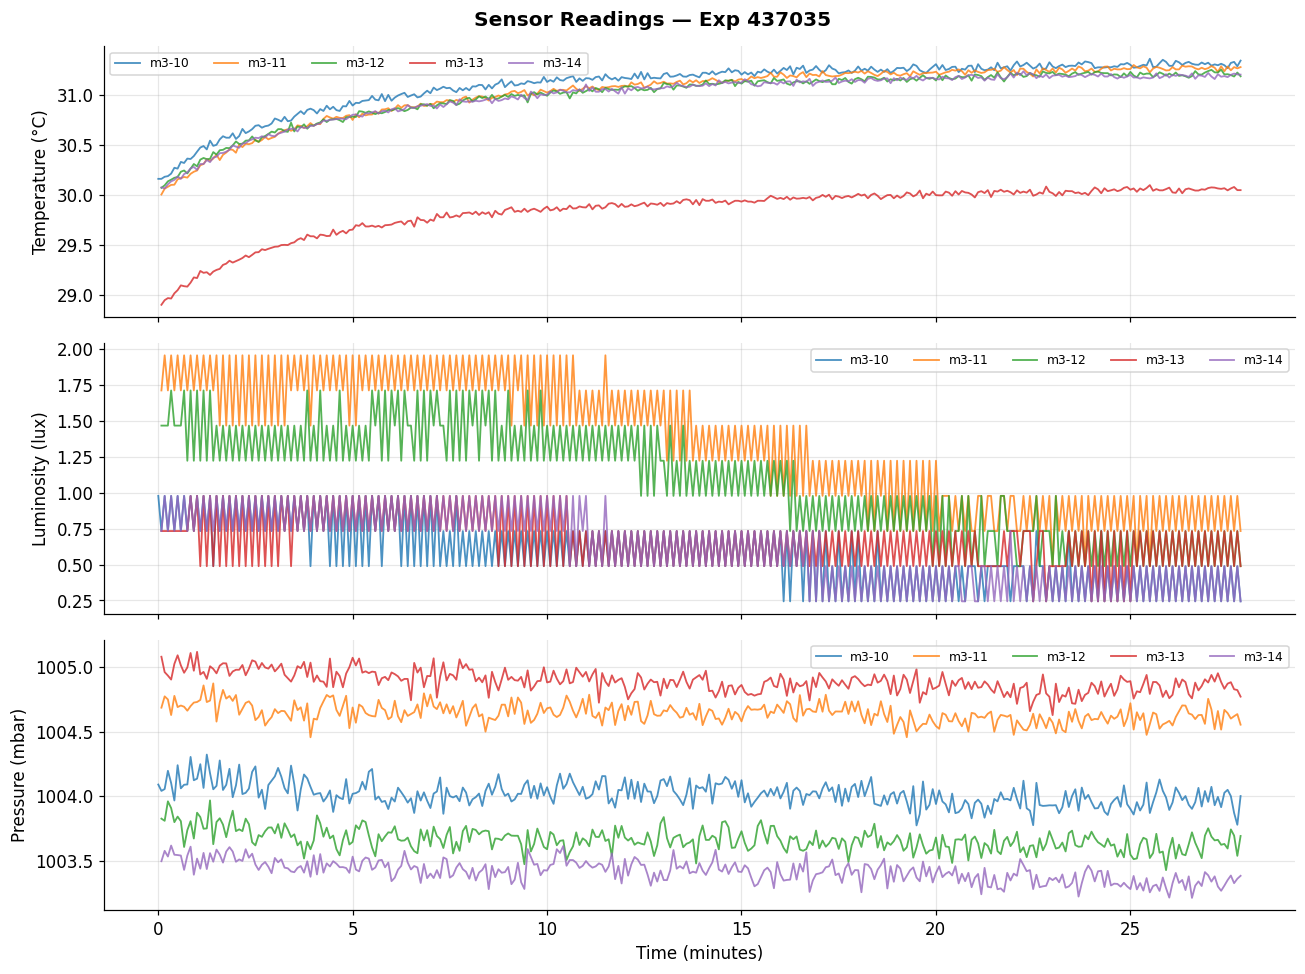

  Saved: sensor_readings.png


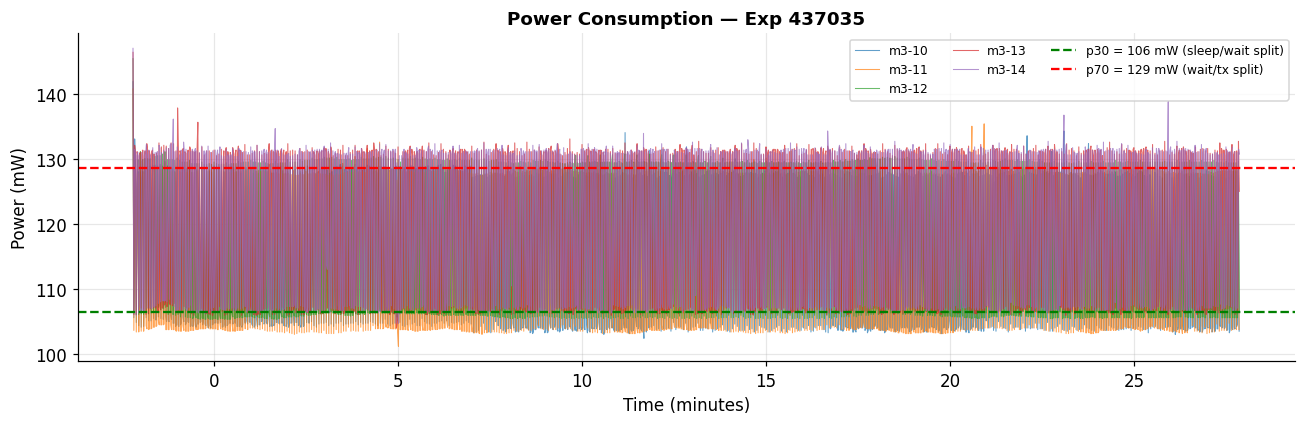

  Saved: power_consumption.png


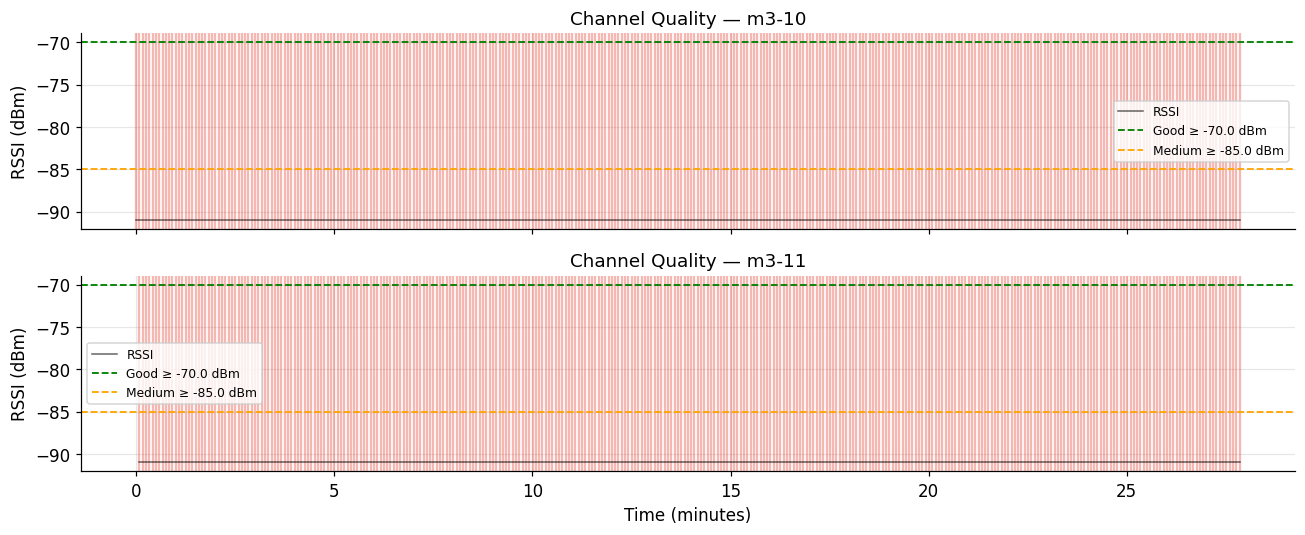

  Saved: channel_quality.png


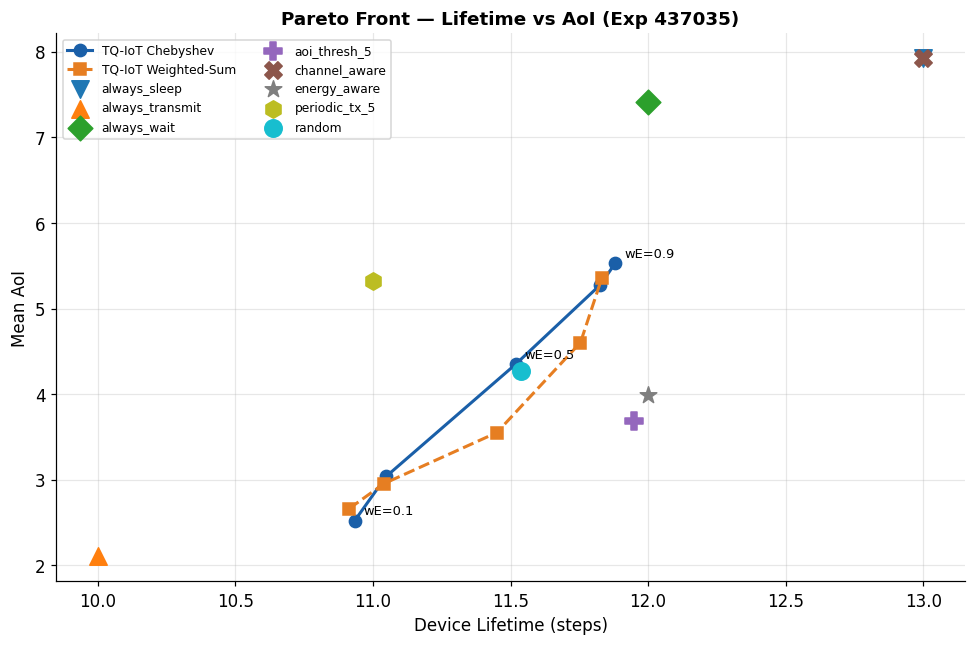

  Saved: pareto_front.png


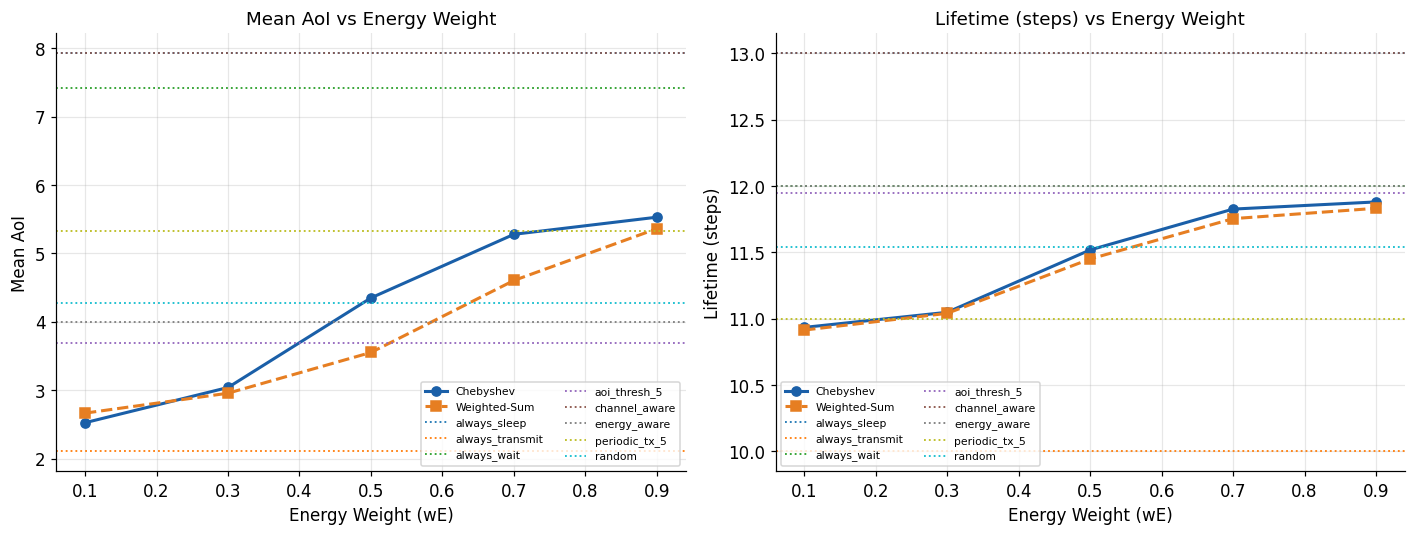

  Saved: tradeoff_curves.png


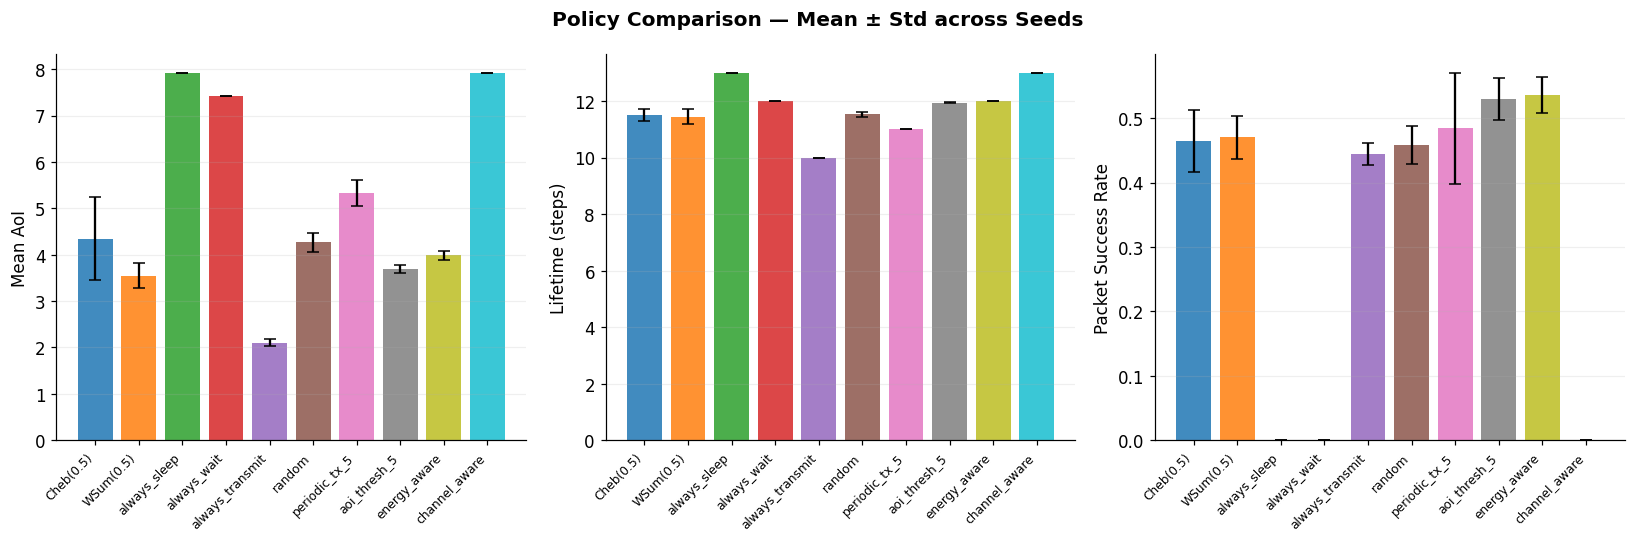

  Saved: policy_comparison.png


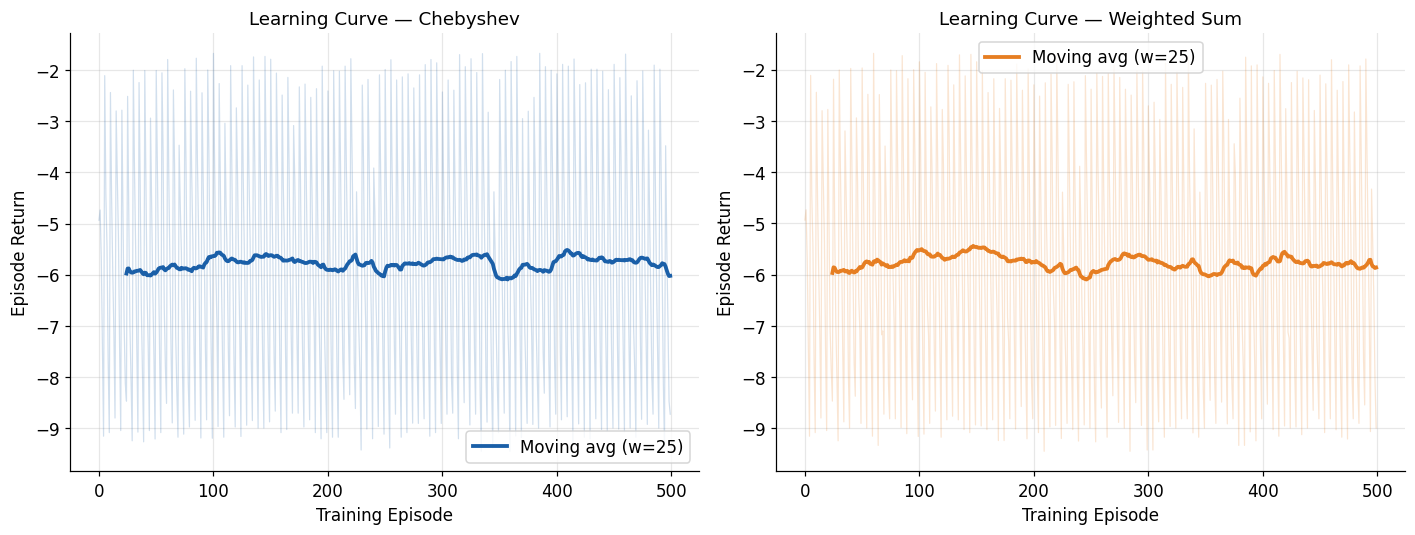

  Saved: learning_curve.png


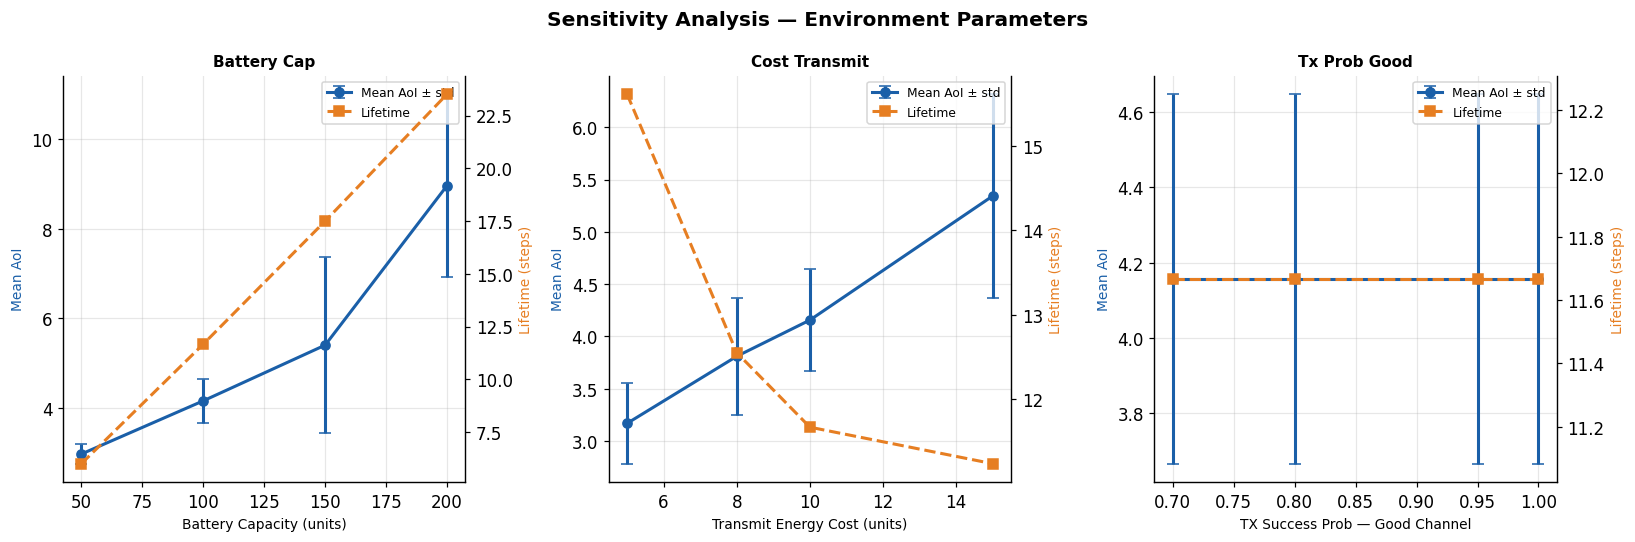

  Saved: sensitivity.png


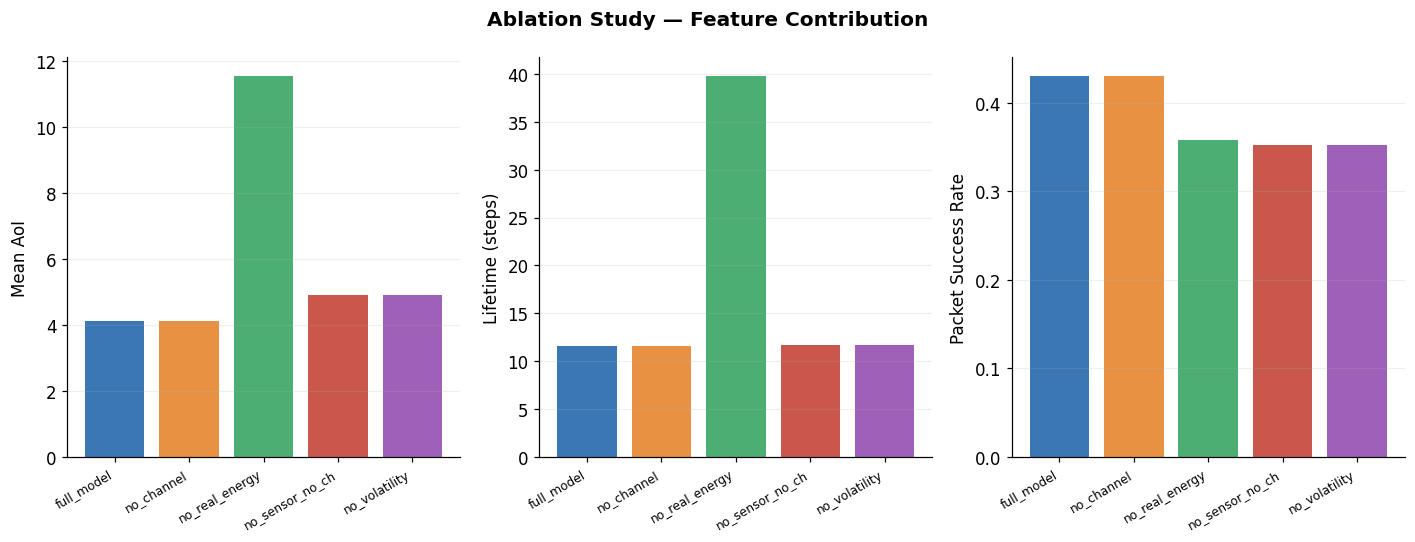

  Saved: ablation.png


In [18]:
def savefig(name: str):
    p = FIGURES / f"{name}.png"
    plt.savefig(p, dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"  Saved: {name}.png")

cheb_df  = all_df[all_df['method'] == 'chebyshev']
wsum_df  = all_df[all_df['method'] == 'weighted_sum']
base_df  = all_df[all_df['method'] == 'baseline']
cheb_m   = cheb_df.groupby('wE').mean(numeric_only=True).reset_index()
wsum_m   = wsum_df.groupby('wE').mean(numeric_only=True).reset_index()
base_sum = base_df.groupby('policy').mean(numeric_only=True)
BLC      = plt.cm.tab10(np.linspace(0, 1, len(base_sum)))
BLM      = ['v', '^', 'D', 'P', 'X', '*', 'h', 'o']

# ── 1. Sensor readings over time ──────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle(f'Sensor Readings — Exp {EXPERIMENT_ID}', fontweight='bold')
for ax, col_name, ylabel in zip(axes,
    ['temperature', 'luminosity', 'pressure'],
    ['Temperature (°C)', 'Luminosity (lux)', 'Pressure (mbar)']):
    for node in sorted(trace_df['node_id'].unique()):
        sub = trace_df[trace_df['node_id'] == node]
        ax.plot(sub['time_s']/60, sub[col_name], lw=1.2, label=node, alpha=0.8)
    ax.set_ylabel(ylabel); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8, ncol=5)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
axes[-1].set_xlabel('Time (minutes)')
plt.tight_layout()
savefig("sensor_readings")

# ── 2. Power consumption over time ────────────────────────────────────────────
if not power_df.empty:
    fig, ax = plt.subplots(figsize=(12, 4))
    for node in sorted(power_df['node_id'].unique()):
        sub = power_df[power_df['node_id'] == node].iloc[::20]
        ax.plot(sub['time_s']/60, sub['power_mw'], lw=0.7, alpha=0.7, label=node)
    ax.axhline(ecosts['p30_mw'], color='green', ls='--', lw=1.5,
               label=f"p30 = {ecosts['p30_mw']:.0f} mW (sleep/wait split)")
    ax.axhline(ecosts['p70_mw'], color='red',   ls='--', lw=1.5,
               label=f"p70 = {ecosts['p70_mw']:.0f} mW (wait/tx split)")
    ax.set_xlabel('Time (minutes)'); ax.set_ylabel('Power (mW)')
    ax.set_title(f'Power Consumption — Exp {EXPERIMENT_ID}', fontweight='bold')
    ax.legend(fontsize=8, ncol=3); ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    plt.tight_layout()
    savefig("power_consumption")

# ── 3. Channel quality over time ──────────────────────────────────────────────
nodes_list = sorted(trace_df['node_id'].unique())
fig, axes  = plt.subplots(min(2, len(nodes_list)), 1,
                           figsize=(12, 5), sharex=True)
axes = [axes] if len(nodes_list) == 1 else list(axes)
cmap_cq = {0: '#e74c3c', 1: '#f39c12', 2: '#2ecc71'}
for ax, node in zip(axes, nodes_list[:2]):
    sub = trace_df[trace_df['node_id'] == node]
    for _, row in sub.iterrows():
        ax.axvline(row['time_s']/60, color=cmap_cq[row['channel_quality']],
                   alpha=0.4, lw=1.5)
    ax.plot(sub['time_s']/60, sub['rssi'], 'k-', lw=1, alpha=0.6, label='RSSI')
    ax.axhline(RSSI_GOOD,   color='green',  ls='--', lw=1.2,
               label=f'Good ≥ {RSSI_GOOD} dBm')
    ax.axhline(RSSI_MEDIUM, color='orange', ls='--', lw=1.2,
               label=f'Medium ≥ {RSSI_MEDIUM} dBm')
    ax.set_ylabel('RSSI (dBm)')
    ax.set_title(f'Channel Quality — {node}')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
axes[-1].set_xlabel('Time (minutes)')
plt.tight_layout()
savefig("channel_quality")

# ── 4. Pareto front ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(cheb_m['lifetime'], cheb_m['mean_aoi'],
        'o-', color='#1a5fa8', lw=2, ms=8, label='TQ-IoT Chebyshev')
ax.plot(wsum_m['lifetime'], wsum_m['mean_aoi'],
        's--', color='#e67e22', lw=2, ms=8, label='TQ-IoT Weighted-Sum')
for (bl, row), col, mk in zip(base_sum.iterrows(), BLC, BLM):
    ax.scatter(row['lifetime'], row['mean_aoi'],
               marker=mk, s=130, color=col, zorder=4, label=bl)
for _, row in cheb_m.iterrows():
    if row['wE'] in [0.1, 0.5, 0.9]:
        ax.annotate(f"wE={row['wE']:.1f}",
                    (row['lifetime'], row['mean_aoi']),
                    textcoords='offset points', xytext=(6, 4), fontsize=8.5)
ax.set_xlabel('Device Lifetime (steps)')
ax.set_ylabel('Mean AoI')
ax.set_title(f'Pareto Front — Lifetime vs AoI (Exp {EXPERIMENT_ID})',
             fontweight='bold')
ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
savefig("pareto_front")

# ── 5. Trade-off curves ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for ax, metric, ylabel in [(ax1, 'mean_aoi', 'Mean AoI'),
                            (ax2, 'lifetime', 'Lifetime (steps)')]:
    ax.plot(cheb_m['wE'], cheb_m[metric], 'o-', color='#1a5fa8',
            lw=2, ms=6, label='Chebyshev')
    ax.plot(wsum_m['wE'], wsum_m[metric], 's--', color='#e67e22',
            lw=2, ms=6, label='Weighted-Sum')
    for (bl, row), col in zip(base_sum.iterrows(), BLC):
        ax.axhline(row[metric], ls=':', lw=1.2, color=col, label=bl)
    ax.set_xlabel('Energy Weight (wE)'); ax.set_ylabel(ylabel)
    ax.set_title(f'{ylabel} vs Energy Weight')
    ax.legend(fontsize=7, ncol=2); ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
savefig("tradeoff_curves")

# ── 6. Policy comparison bar chart ────────────────────────────────────────────
comp = {}
comp['Cheb(0.5)'] = cheb_df[cheb_df['wE'] == 0.5]
comp['WSum(0.5)'] = wsum_df[wsum_df['wE'] == 0.5]
for bl in BASELINES:
    comp[bl] = base_df[base_df['policy'] == bl]
names   = list(comp.keys())
bar_col = plt.cm.tab10(np.linspace(0, 1, len(names)))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Policy Comparison — Mean ± Std across Seeds', fontweight='bold')
for ax, metric, ylabel in zip(axes,
    ['mean_aoi', 'lifetime', 'pkt_success_rate'],
    ['Mean AoI', 'Lifetime (steps)', 'Packet Success Rate']):
    means = [comp[n][metric].mean() for n in names]
    stds  = [comp[n][metric].std()  for n in names]
    ax.bar(range(len(names)), means, yerr=stds, color=bar_col,
           alpha=0.85, capsize=4, error_kw={'lw': 1.5})
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel(ylabel); ax.grid(True, alpha=0.2, axis='y')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
savefig("policy_comparison")

# ── 7. Learning curve ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, method, col in zip(axes,
    ['chebyshev', 'weighted_sum'],
    ['#1a5fa8', '#e67e22']):
    if method not in ep_rewards_log or not ep_rewards_log[method]:
        ax.set_visible(False); continue
    rw = np.array(ep_rewards_log[method])
    w  = max(1, min(50, len(rw) // 20))
    ma = np.convolve(rw, np.ones(w) / w, mode='valid')
    ax.plot(rw, alpha=0.2, color=col, lw=0.8)
    ax.plot(range(w - 1, len(rw)), ma, color=col, lw=2.5,
            label=f'Moving avg (w={w})')
    ax.set_xlabel('Training Episode')
    ax.set_ylabel('Episode Return')
    ax.set_title(f'Learning Curve — {method.replace("_", " ").title()}')
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
savefig("learning_curve")

# ── 8. Sensitivity ────────────────────────────────────────────────────────────
# Three parameters in a clean 1×3 layout.
# aoi_stale excluded — only affects reporting, not environment dynamics.
_sens_params_ordered = ['battery_cap', 'cost_transmit', 'tx_prob_good']
_xlabels = {
    'battery_cap'  : 'Battery Capacity (units)',
    'cost_transmit': 'Transmit Energy Cost (units)',
    'tx_prob_good' : 'TX Success Prob — Good Channel',
}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Sensitivity Analysis — Environment Parameters', fontweight='bold')

for ax, param in zip(axes, _sens_params_ordered):
    sub = (sens_df[sens_df['param'] == param]
           .groupby('value')
           .agg(aoi_m=('mean_aoi', 'mean'),
                aoi_s=('mean_aoi', 'std'),
                lt_m =('lifetime', 'mean'))
           .reset_index())

    ax2 = ax.twinx()
    ax.errorbar(sub['value'], sub['aoi_m'], yerr=sub['aoi_s'],
                color='#1a5fa8', marker='o', lw=2, capsize=4,
                label='Mean AoI ± std')
    ax2.plot(sub['value'], sub['lt_m'], color='#e67e22',
             marker='s', lw=2, ls='--', label='Lifetime')

    ax.set_xlabel(_xlabels[param], fontsize=9)
    ax.set_ylabel('Mean AoI', color='#1a5fa8', fontsize=9)
    ax2.set_ylabel('Lifetime (steps)', color='#e67e22', fontsize=9)
    ax.set_title(param.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    # add legend from both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper right')

plt.tight_layout()
savefig("sensitivity")

# ── 9. Ablation ───────────────────────────────────────────────────────────────
abl_m    = abl_df.groupby('case').mean(numeric_only=True).reset_index()
abl_cols = ['#1a5fa8', '#e67e22', '#2ca05a', '#c0392b', '#8e44ad']
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
fig.suptitle('Ablation Study — Feature Contribution', fontweight='bold')
for ax, metric, ylabel in zip(axes,
    ['mean_aoi', 'lifetime', 'pkt_success_rate'],
    ['Mean AoI', 'Lifetime (steps)', 'Packet Success Rate']):
    ax.bar(abl_m['case'], abl_m[metric], color=abl_cols, alpha=0.85)
    ax.set_xticks(range(len(abl_m)))
    ax.set_xticklabels(abl_m['case'], rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(ylabel); ax.grid(True, alpha=0.2, axis='y')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
savefig("ablation")


## 14. Reproducibility Summary

In [19]:
csvs = sorted(f.name for f in RESULTS.glob("*.csv"))
figs = sorted(f.name for f in FIGURES.glob("*.png"))

n_power = len(list((RAW_DIR/"consumption").glob("*.oml")))           if (RAW_DIR/"consumption").exists() else 0
n_radio = len(list((RAW_DIR/"radio").glob("*.oml")))           if (RAW_DIR/"radio").exists() else 0

print("=" * 65)
print("  REPRODUCIBILITY SUMMARY")
print("=" * 65)
print(f"  Project root        : {ROOT}")
print(f"  Experiment ID       : {EXPERIMENT_ID}")
print(f"  Raw data path       : {RAW_DIR}")
print(f"  Processed data path : {PROCESSED}")
print(f"  Results path        : {RESULTS}")
print(f"  Sensor file         : {sensor_file.name}")
print(f"  Power files loaded  : {n_power}")
print(f"  Radio files loaded  : {n_radio}")
print(f"  Nodes detected      : {sorted(trace_df['node_id'].unique())}")
print(f"  Final trace rows    : {len(trace_df)}")
print(f"  Energy costs        : sleep={COST_SLEEP}  wait={COST_WAIT}  tx={COST_TRANSMIT}")
print(f"  Policies evaluated  : {all_df['policy'].nunique()}")
print(f"  Seeds used          : {SEEDS}")
print(f"  Weight configs      : {WEIGHTS}")
print(f"  Radio-aware         : {HAS_RADIO}")
print()
print(f"  Generated CSVs ({len(csvs)}):")
for f in csvs: print(f"    {f}")
print(f"  Generated PNGs ({len(figs)}):")
for f in figs: print(f"    {f}")
print("=" * 65)


  REPRODUCIBILITY SUMMARY
  Project root        : d:\thesis-iot-scheduling-
  Experiment ID       : 437035
  Raw data path       : d:\thesis-iot-scheduling-\data\raw\exp_437035
  Processed data path : d:\thesis-iot-scheduling-\data\processed\exp_437035
  Results path        : d:\thesis-iot-scheduling-\results\exp_437035
  Sensor file         : exp_437035_sensor_stream_raw.txt
  Power files loaded  : 5
  Radio files loaded  : 5
  Nodes detected      : ['m3-10', 'm3-11', 'm3-12', 'm3-13', 'm3-14']
  Final trace rows    : 1671
  Energy costs        : sleep=8  wait=9  tx=10
  Policies evaluated  : 18
  Seeds used          : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
  Weight configs      : [(0.1, 0.9), (0.3, 0.7), (0.5, 0.5), (0.7, 0.3), (0.9, 0.1)]
  Radio-aware         : True

  Generated CSVs (9):
    ablation_results.csv
    cleaned_power_trace.csv
    cleaned_radio_trace.csv
    cleaned_sensor_trace.csv
    estimated_energy_costs.csv
    final_rl_trace.csv
    metrics_all_seeds.csv
    metrics_su